# 🌸 Iris Flower Species Classification
## Minor Project 1 — Supervised Machine Learning
**Author:** Harsh Verma  
**Dataset:** Iris Dataset (UCI Machine Learning Repository)  
**Problem Type:** Multi-class Classification


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Problem Statement
The Iris dataset is a classic benchmark in machine learning. The goal is to **classify iris flowers 
into three species** — *Setosa*, *Versicolor*, and *Virginica* — based on four morphological features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

This is a **multi-class classification** problem solved using supervised ML algorithms.


In [2]:
# Load Dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print("=== Dataset Statistics ===")
print(df.describe())
print("\nMissing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("\nClass Distribution:")
print(df['species_name'].value_counts())

=== Dataset Statistics ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing Values: 0
Duplicate Rows: 1

Class D

## 2. Exploratory Data Analysis (EDA)

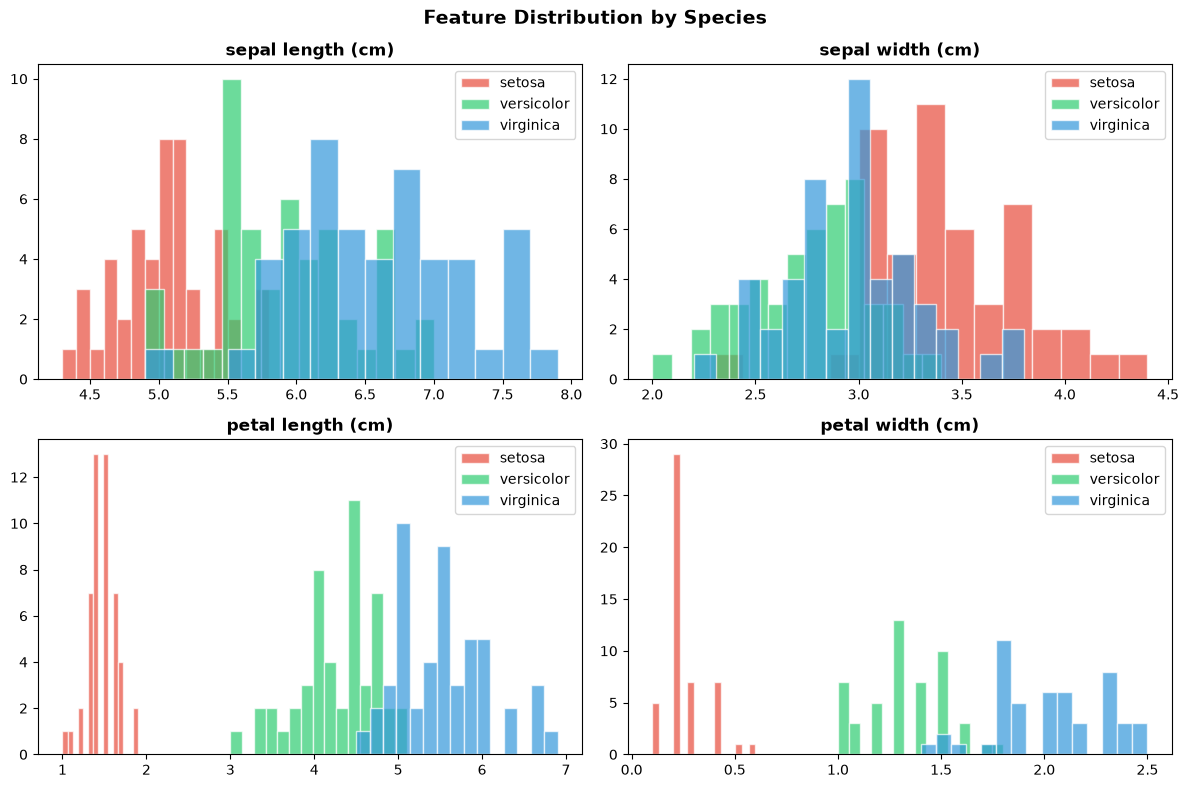

In [4]:
# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = {'setosa':'#e74c3c','versicolor':'#2ecc71','virginica':'#3498db'}
for ax, feat in zip(axes.flatten(), iris.feature_names):
    for name, grp in df.groupby('species_name'):
        ax.hist(grp[feat], alpha=0.7, label=name, color=colors[name], bins=15, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distribution by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

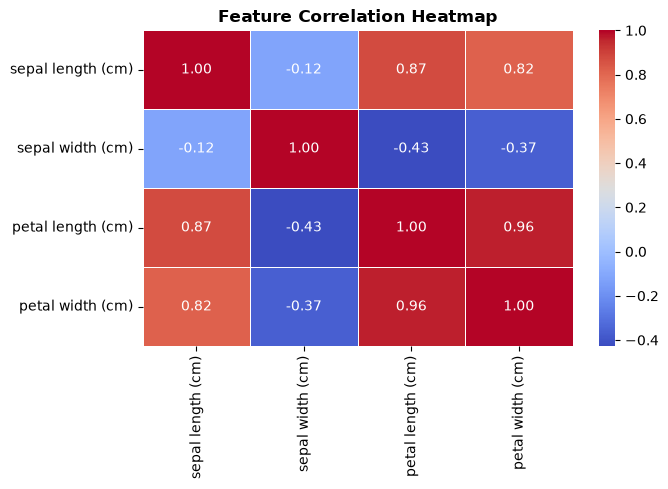

In [5]:
# Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [6]:
# Train-Test Split + StandardScaler
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples: {X_train_sc.shape[0]}")
print(f"Testing  samples: {X_test_sc.shape[0]}")

Training samples: 120
Testing  samples: 30


## 4. Model Development & Evaluation

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted'), 4),
    }

res_df = pd.DataFrame(results).T
print(res_df)

                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9333     0.9333  0.9333    0.9333
Decision Tree          0.9333     0.9333  0.9333    0.9333
Random Forest          0.9000     0.9024  0.9000    0.8997
SVM                    0.9667     0.9697  0.9667    0.9666
KNN                    0.9333     0.9444  0.9333    0.9327


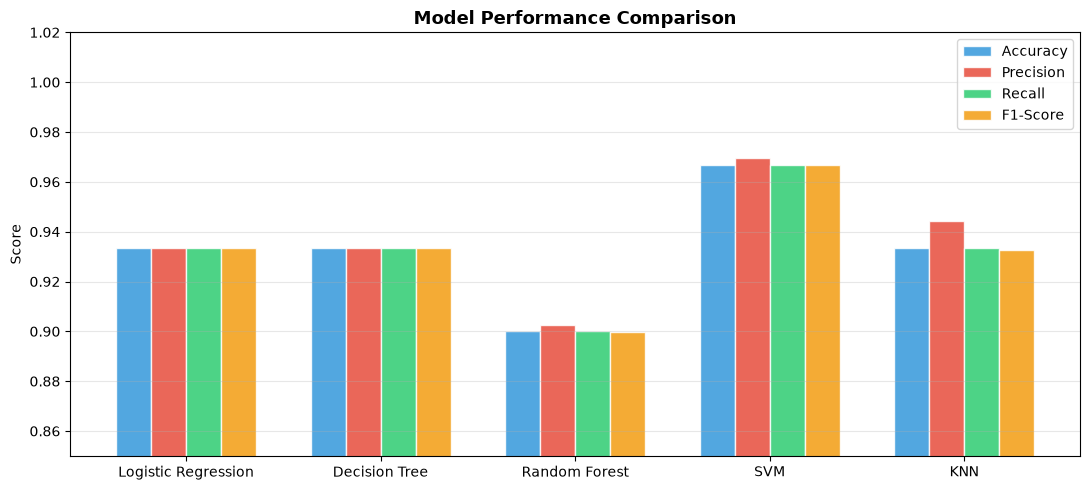

In [8]:
# Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(res_df.index))
w = 0.18
palette = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1-Score'], palette)):
    ax.bar(x + i*w, res_df[metric], w, label=metric, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(res_df.index, fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score'); ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

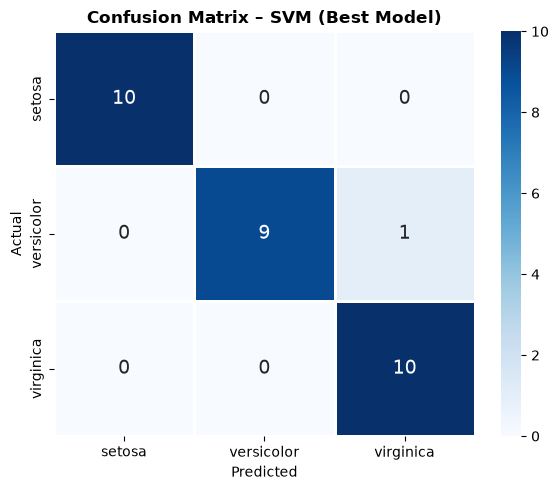


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [9]:
# Confusion Matrix — Best Model (SVM)
best_model = SVC(kernel='rbf', random_state=42)
best_model.fit(X_train_sc, y_train)
y_pred_best = best_model.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            linewidths=1, annot_kws={'size':14})
plt.title('Confusion Matrix – SVM (Best Model)', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

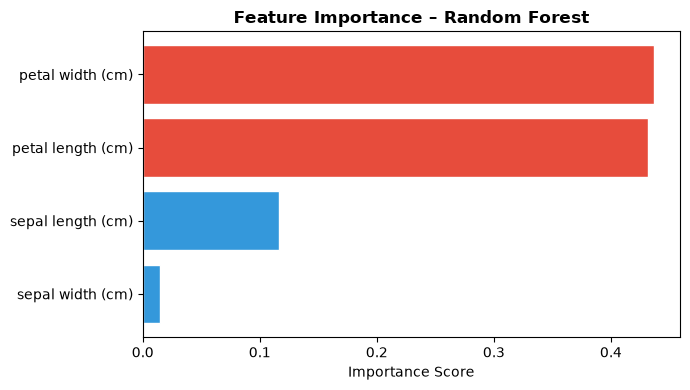

In [10]:
# Feature Importance — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
fi_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=True)
plt.figure(figsize=(7,4))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=['#3498db','#3498db','#e74c3c','#e74c3c'], edgecolor='white')
plt.title('Feature Importance – Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

In [11]:
# Save Models
import os
os.makedirs('../model', exist_ok=True)
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    joblib.dump(model, f"../model/{name.replace(' ','_')}.pkl")
joblib.dump(scaler, '../model/scaler.pkl')
print("All models saved to model/ directory!")

All models saved to model/ directory!


## 5. Conclusion

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 93.33% |
| Decision Tree | 93.33% |
| Random Forest | 90.00% |
| **SVM** | **96.67%** |
| KNN | 93.33% |

- **Best Model:** Support Vector Machine (SVM) with RBF kernel — **96.67% accuracy**
- **Key Features:** Petal length and petal width are the most discriminative features
- **Dataset Quality:** No missing values; well-balanced classes (50 samples per species)
- All models performed above 90%, confirming the dataset is highly separable

**Dataset Source:** [UCI Machine Learning Repository – Iris Dataset](https://archive.ics.uci.edu/ml/datasets/iris)
